In [ ]:
import os
import sys
import zipfile
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# 如果是在 Colab，先挂载 Google Drive
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:

BASE_DIR = "/content/drive/MyDrive/Google AI Studio"


IPYNB_PATH = os.path.join(BASE_DIR, "ResNet50_Model_with_balanced_classes_via_image_augmentation (2).ipynb")
CKPT_PATH = os.path.join(BASE_DIR, "checkpoint_resnet50_balanced.pt")
ZIP_PATH = os.path.join(BASE_DIR, "chest_xray_resized_new_FIXED.zip")
DATA_ROOT = os.path.join(BASE_DIR, "chest_xray_resized_new")


SAVE_DIR = os.path.join(BASE_DIR, "gradcam_results")
os.makedirs(SAVE_DIR, exist_ok=True)


sys.path.append(BASE_DIR)
from pneumonia_model_utils import get_resnet50_model

print("BASE_DIR:", BASE_DIR)
print("CKPT_PATH:", CKPT_PATH)
print("ZIP_PATH:", ZIP_PATH)
print("DATA_ROOT:", DATA_ROOT)
print("SAVE_DIR:", SAVE_DIR)

BASE_DIR: /content/drive/MyDrive/Google AI Studio
CKPT_PATH: /content/drive/MyDrive/Google AI Studio/checkpoint_resnet50_balanced.pt
ZIP_PATH: /content/drive/MyDrive/Google AI Studio/chest_xray_resized_new_FIXED.zip
DATA_ROOT: /content/drive/MyDrive/Google AI Studio/chest_xray_resized_new
SAVE_DIR: /content/drive/MyDrive/Google AI Studio/gradcam_results


In [ ]:

TEST_DIR = os.path.join(DATA_ROOT, "test")

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_resnet50_model(device)
ckpt = torch.load(CKPT_PATH, map_location=device)

if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)

model = model.to(device)
model.eval()

for p in model.parameters():
    p.requires_grad = True

print("Model loaded.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]


Model loaded.


In [ ]:
TEST_DIR = os.path.join(DATA_ROOT, "test")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = ImageFolder(TEST_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

class_names = dataset.classes
print("Classes:", class_names)
print("Test images:", len(dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Test images: 624


In [ ]:
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for x, y in loader:
        x = x.to(device)
        out = model(x)
        prob = torch.softmax(out, dim=1)

        all_probs.append(prob.cpu())
        all_preds.append(prob.argmax(dim=1).cpu())
        all_labels.append(y)

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

confidence = all_probs.max(axis=1)
correct = (all_preds == all_labels)

print("Accuracy:", correct.mean())

Accuracy: 0.8830128205128205


In [ ]:
df = pd.DataFrame({
    "index": range(len(dataset.samples)),
    "image_path": [p for p, _ in dataset.samples],
    "true_label": all_labels,
    "pred_label": all_preds,
    "true_class": [class_names[i] for i in all_labels],
    "pred_class": [class_names[i] for i in all_preds],
    "confidence": confidence,
    "correct": correct
})


selected = []

for cls in class_names:
    tmp = df[(df["true_class"] == cls) & (df["correct"] == True)]
    tmp = tmp.sort_values("confidence", ascending=False).head(2)
    selected.append(tmp)

wrong = df[df["correct"] == False].sort_values("confidence", ascending=False).head(4)
selected.append(wrong)

selected_df = pd.concat(selected).reset_index(drop=True)
selected_df

,index,image_path,true_label,pred_label,true_class,pred_class,confidence,correct
0,10,/content/drive/MyDrive/Google AI Studio/chest_...,0,0,NORMAL,NORMAL,0.998412,True
1,123,/content/drive/MyDrive/Google AI Studio/chest_...,0,0,NORMAL,NORMAL,0.997257,True
2,434,/content/drive/MyDrive/Google AI Studio/chest_...,1,1,PNEUMONIA,PNEUMONIA,1.000000,True
3,285,/content/drive/MyDrive/Google AI Studio/chest_...,1,1,PNEUMONIA,PNEUMONIA,1.000000,True
4,165,/content/drive/MyDrive/Google AI Studio/chest_...,0,1,NORMAL,PNEUMONIA,0.999970,False
5,160,/content/drive/MyDrive/Google AI Studio/chest_...,0,1,NORMAL,PNEUMONIA,0.999779,False
6,192,/content/drive/MyDrive/Google AI Studio/chest_...,0,1,NORMAL,PNEUMONIA,0.994155,False
7,15,/content/drive/MyDrive/Google AI Studio/chest_...,0,1,NORMAL,PNEUMONIA,0.992283,False


In [ ]:
!pip install grad-cam



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 109.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=7b561b558a8944b2a752e9b7b1d3065d24013c382b0f63970e0a7941030bcdac
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

In [ ]:
def denormalize(x):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    x = x.permute(1, 2, 0).cpu().numpy()
    x = x * std + mean
    x = np.clip(x, 0, 1)
    return x


def make_gradcam(img_path, pred_label):
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    rgb_img = denormalize(input_tensor[0])

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(int(pred_label))]
    )[0]

    overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return rgb_img, grayscale_cam, overlay

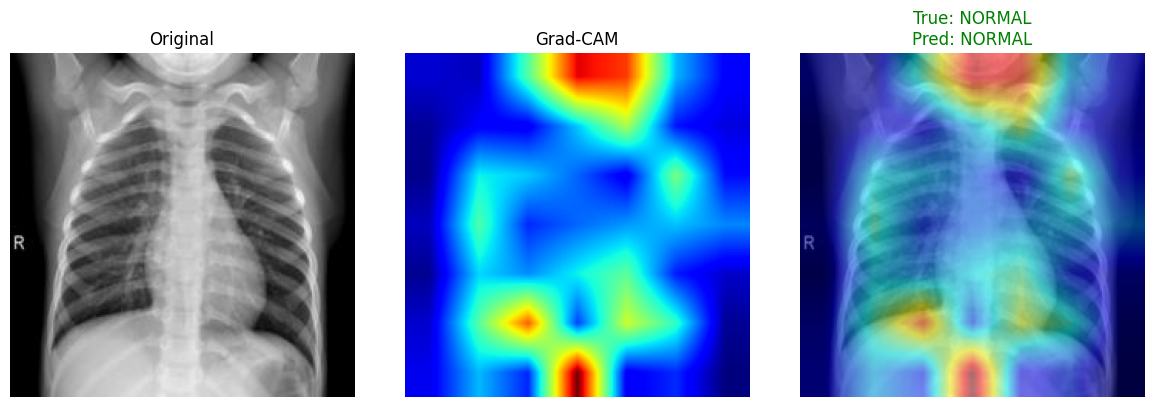

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_0_true_NORMAL_pred_NORMAL.png


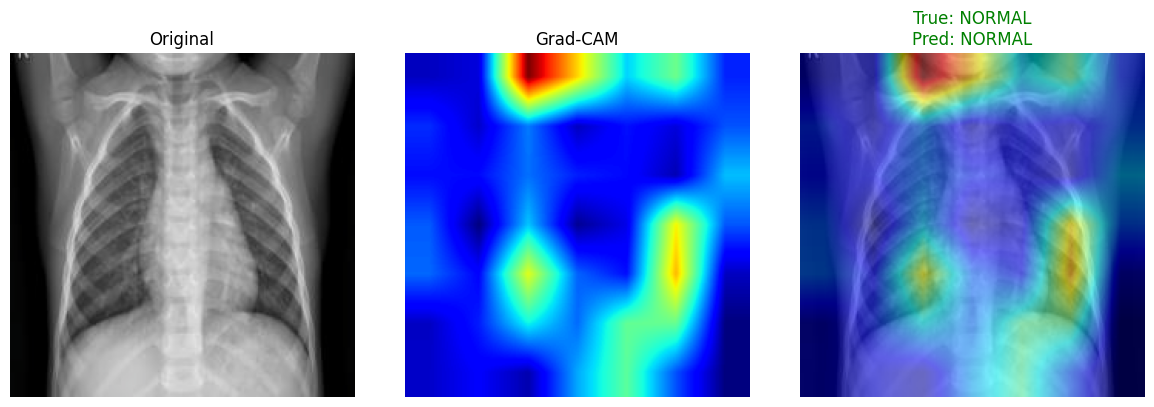

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_1_true_NORMAL_pred_NORMAL.png


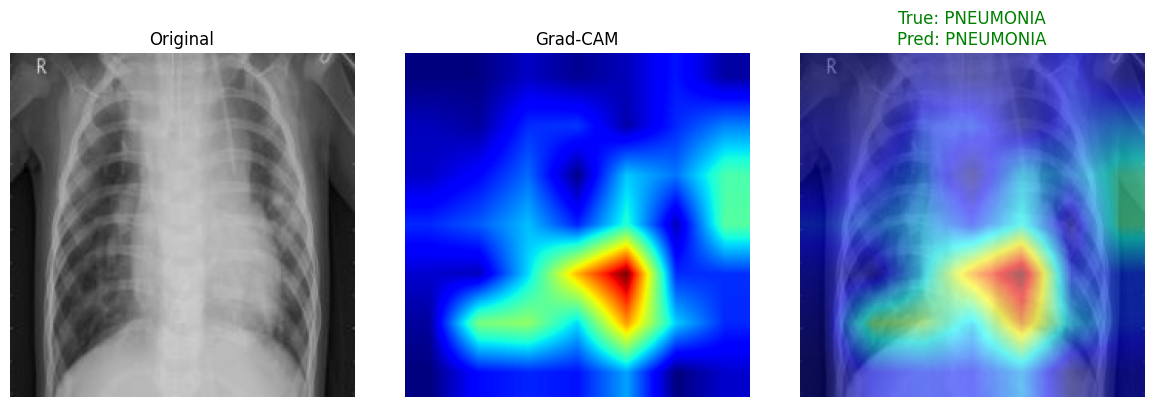

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_2_true_PNEUMONIA_pred_PNEUMONIA.png


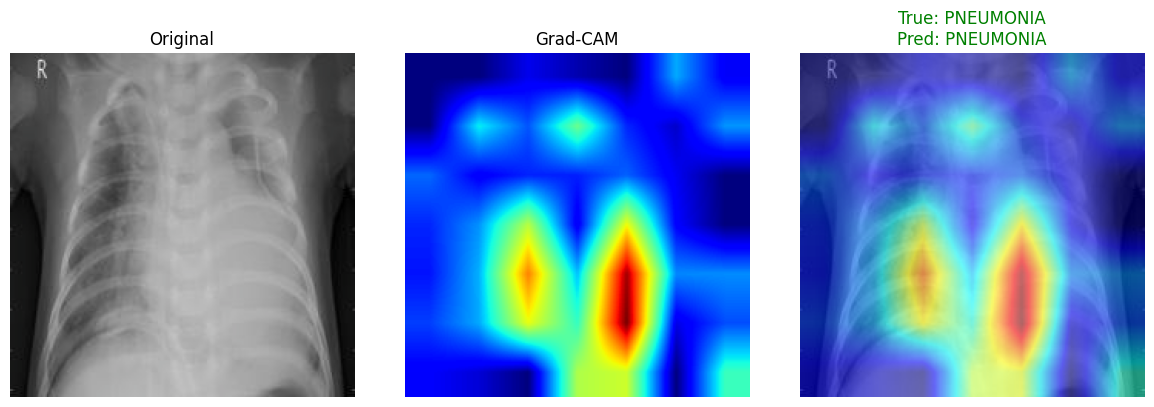

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_3_true_PNEUMONIA_pred_PNEUMONIA.png


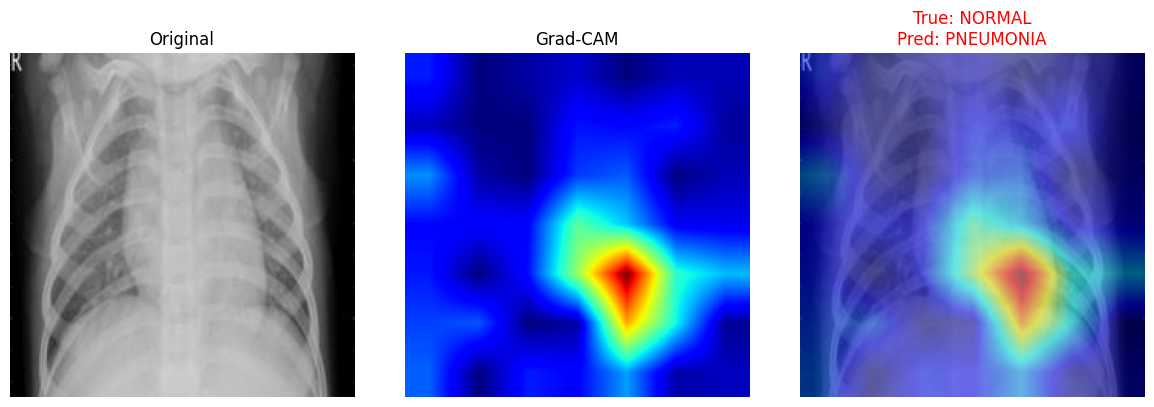

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_4_true_NORMAL_pred_PNEUMONIA.png


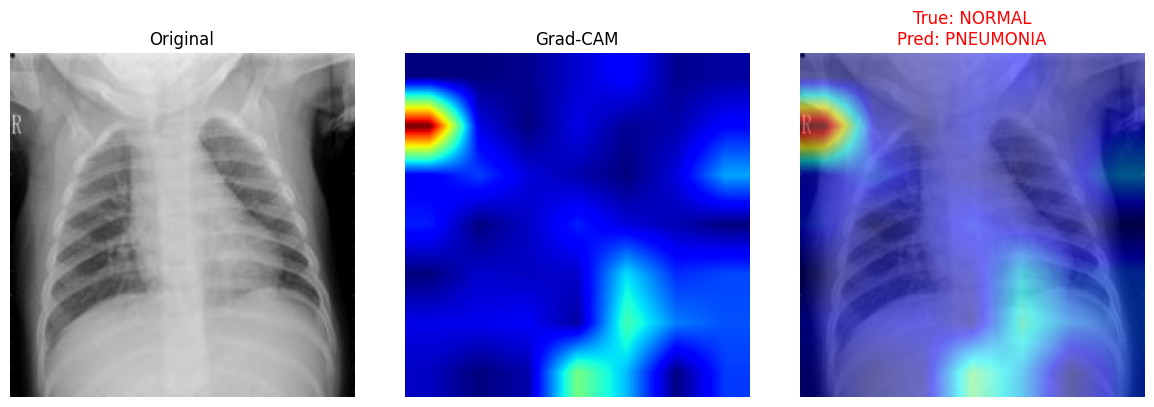

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_5_true_NORMAL_pred_PNEUMONIA.png


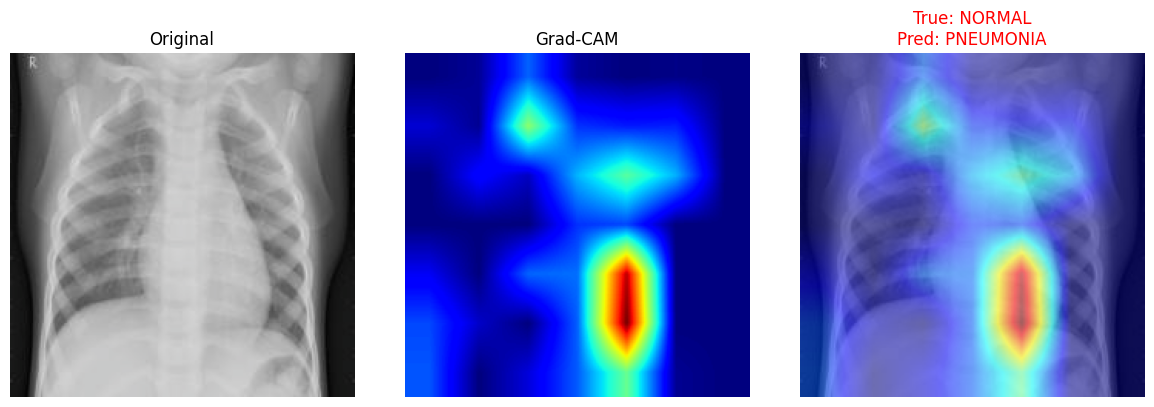

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_6_true_NORMAL_pred_PNEUMONIA.png


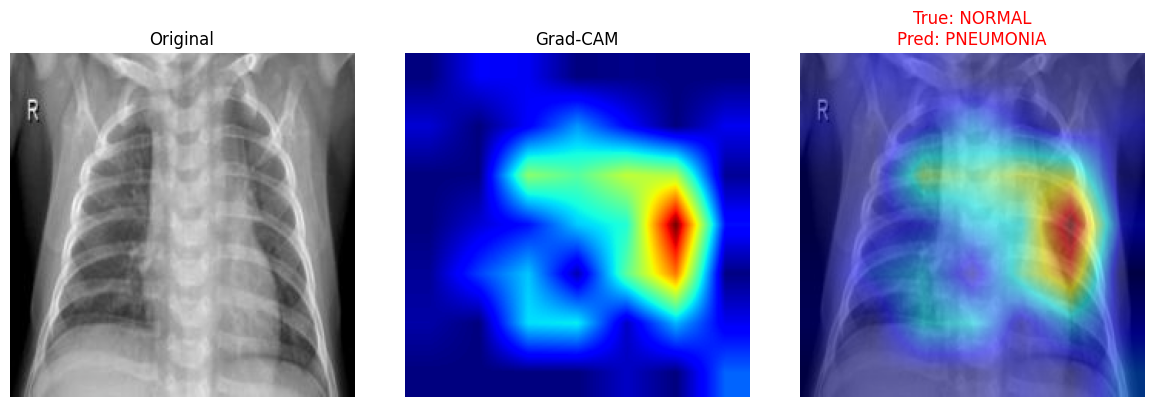

Saved: /content/drive/MyDrive/Google AI Studio/gradcam_results/gradcam_7_true_NORMAL_pred_PNEUMONIA.png


In [ ]:
for i, row in selected_df.iterrows():

    rgb_img, heatmap, overlay = make_gradcam(
        row["image_path"],
        row["pred_label"]
    )

    title_color = "green" if row["correct"] else "red"

    save_path = os.path.join(
        SAVE_DIR,
        f"gradcam_{i}_true_{row['true_class']}_pred_{row['pred_class']}.png"
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"True: {row['true_class']}\nPred: {row['pred_class']}",
        color=title_color
    )
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)